In [1]:
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
from gstatot import StatOT, gStatOT, Metric_Evaluator, utils

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [2]:
# The synthetic data, bistable_sim_0.h5ad, can be downloaded at https://doi.org/10.5281/zenodo.20723235
# or generated by running the make_bistable_sims.py script in extra/data_preprocessing/sim
data_dir = '../extra/data/sim_data/bistable_simulations'
sim_adata = sc.read_h5ad(f"{data_dir}/bistable_sim_seed=0.h5ad") # load sim adata with ground truth trajectories and fate probability estimates

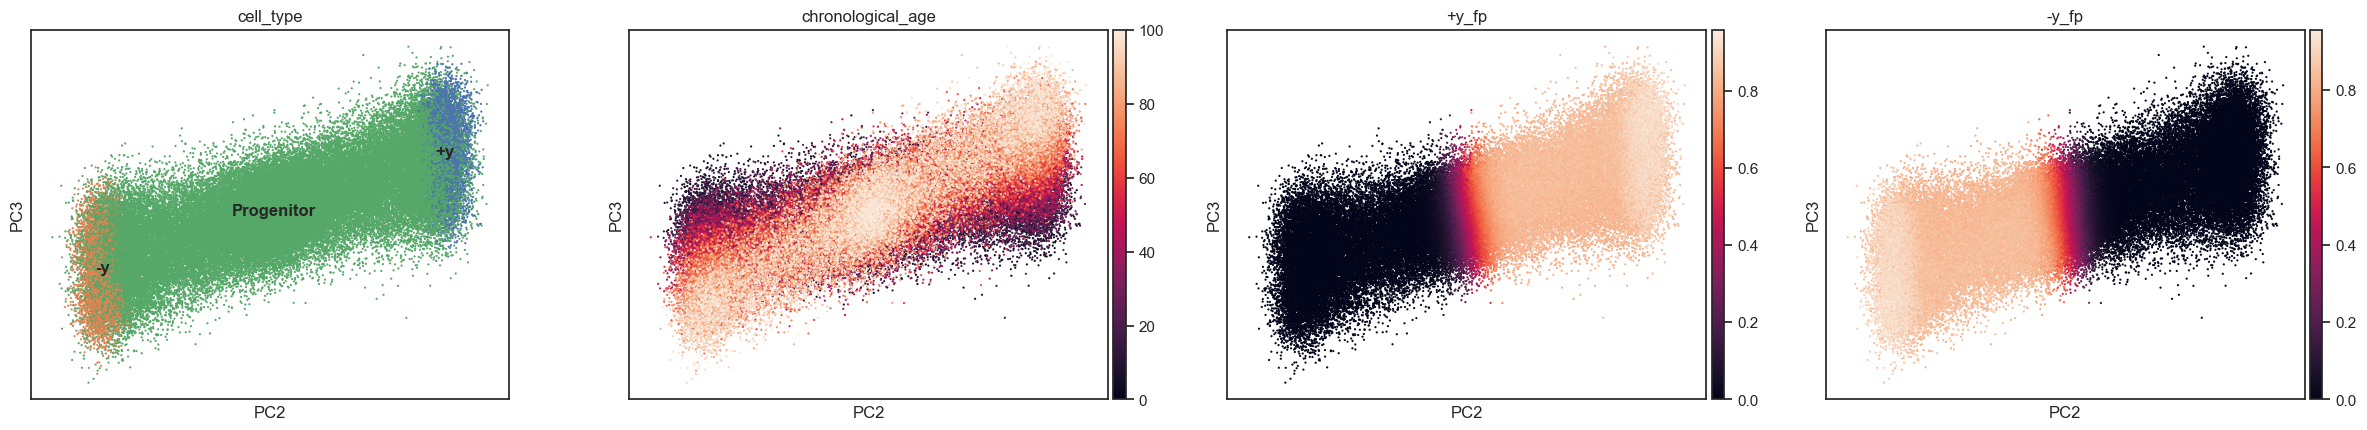

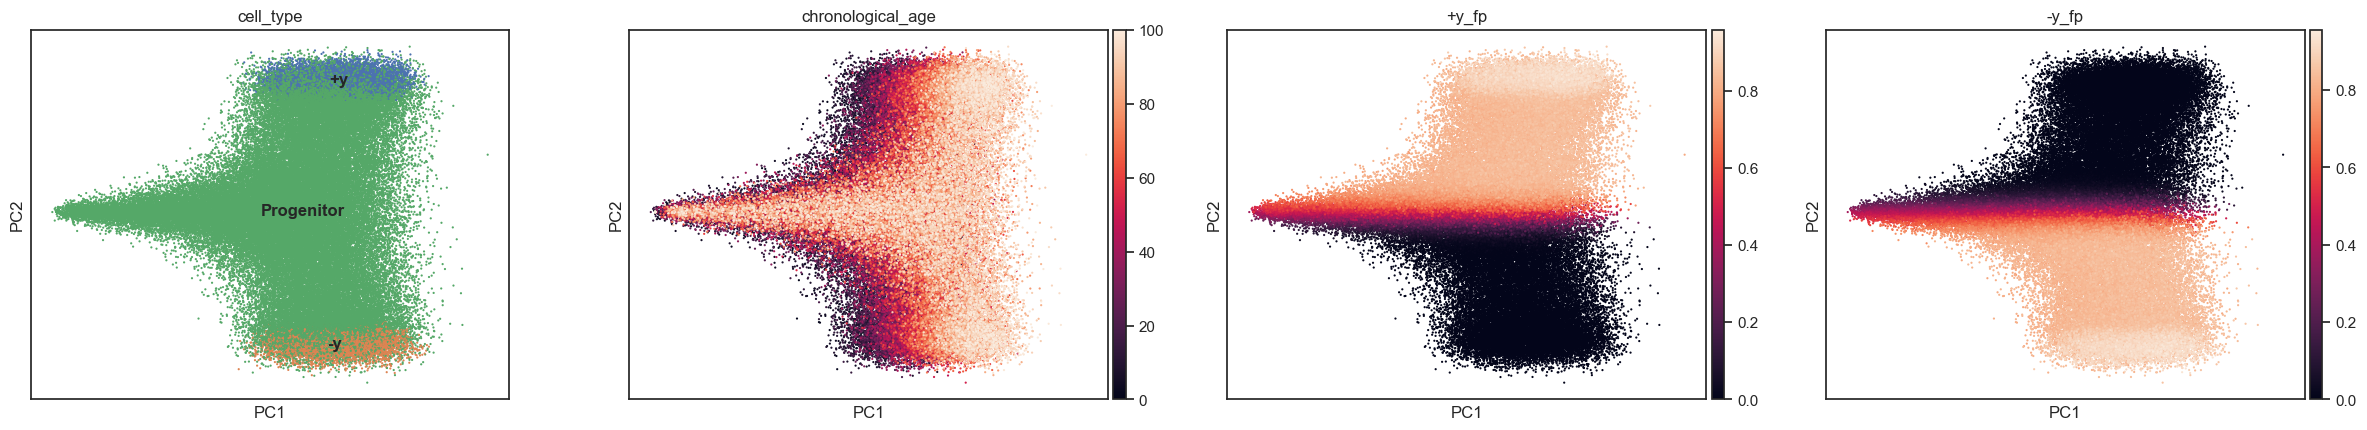

In [3]:
# +/-y is +/-2 in the manuscript
sim_adata.obs['+y_fp'] = sim_adata.obsm['cell_type_fp'][:,0]
sim_adata.obs['-y_fp'] = sim_adata.obsm['cell_type_fp'][:,1]
sc.pl.pca(sim_adata, color=['cell_type', 'chronological_age', '+y_fp', '-y_fp'], components=['2,3'], size=10, legend_loc='on data')
sc.pl.pca(sim_adata, color=['cell_type', 'chronological_age', '+y_fp', '-y_fp'], components=['1,2'], size=10, legend_loc='on data')

In [4]:
# set time points for time coureses
ages = np.asarray(sim_adata.obs['chronological_age'].unique())
age_span = ages.max() - ages.min()
T_list = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
first_time = 2
final_time = 99
time_lists = {}
for T in T_list:
    theo_times = np.linspace(first_time, final_time, T, dtype=int)
    time_lists[T] = theo_times

# global parameters

key = 42 # seed for random number generator
#n = 200 # number of cells per time point
T = 25
n = 10
chosen_times = time_lists[T] 

# trajectory sampling parameters
sim_dt = dt =  0.01
num_step = int(2/dt) # 2 days
num_traj = sim_adata.uns['true_traj_data']['0.0'].shape[0] # 500 


adata_keys  = {'time_key': 'chronological_age', # key in adata.obs for age annotation
               'cell_type_key': 'cell_type', # key in adata.obs for cell type annotation
               'growth_rate_key': 'growth_rate', # key in adata.obs for cell growth rates
               'embed_key': 'X_pca'}

In [5]:
downsampled_adata = utils.downsample_adata_by_age(sim_adata, n=n, time_key=adata_keys['time_key'], 
                                                       PRNG_KEY=key, chosen_times=chosen_times)

# gStatOT

Using optimal parameters for T=25: lam=15.0, epsilon2=0.01
Ran 3700 iterations in 0.07 minutes.
duality gap: 9.547e-04
max constraint error: 6.129e-06



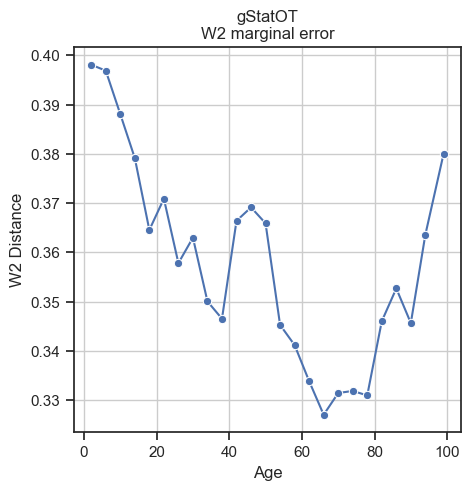

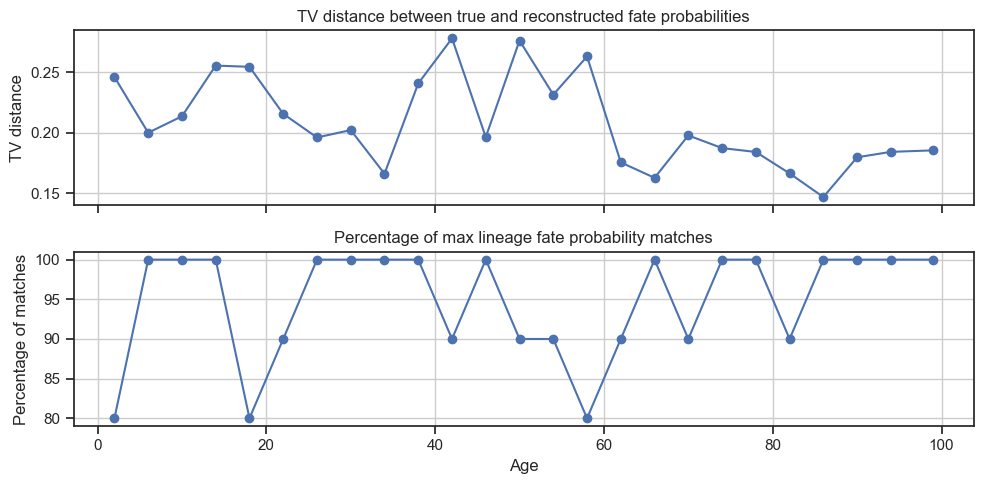

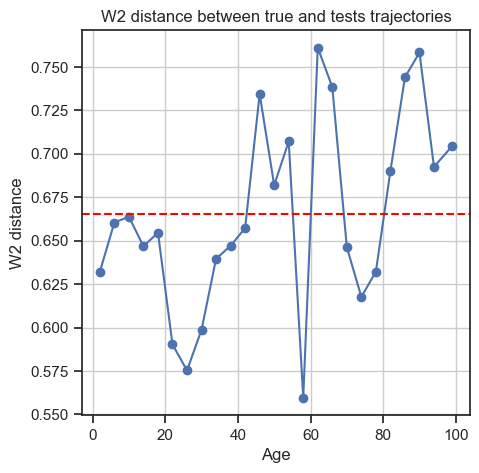

In [6]:

gSOT = gStatOT(adata=downsampled_adata.copy(), adata_keys=adata_keys, dt=dt, dtype=jnp.float32)

# For n = 10 opt params
opt_params = pd.read_csv('../extra/sweeps/sim/gStatOT_opt_vals_sim.csv', index_col=0)
lam = opt_params.loc[T]['lam']
epsilon2 = opt_params.loc   [T]['epsilon2']
print(f"Using optimal parameters for T={T}: lam={lam}, epsilon2={epsilon2}")
model_params = {'lam': lam,
                'epsilon2': epsilon2,
}

gSOT.fit(model_params=model_params, 
         verbose=True,
          tol=1e-3)

gSOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                        all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))

gSOT.get_trajectories(num_traj=num_traj, num_step=num_step)
method_str = 'gStatOT' 

gsot_metric_tests = Metric_Evaluator(method=method_str,
                                        test_adata=gSOT.adata,
                                        true_adata=sim_adata,
                                        time_key=adata_keys['time_key'],
                                        embed_key=adata_keys['embed_key'],
                                        exp_dir=None,
                                        full_supp=True)

gsot_metric_tests.w2_marginal_error()
gsot_metric_tests.fp_tv_error(label_key=adata_keys['cell_type_key'])
gsot_metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)

In [7]:
gSOT.adata 

AnnData object with n_obs × n_vars = 250 × 10
    obs: 'growth_rate', 'chronological_age', 'cell_type', 'sink', 'source', '+y_fp', '-y_fp', 'Progenitor_fp'
    uns: 'all_cell_types', 'true_dt', 'true_traj_data', 'true_traj_metadata', 'cell_type_colors', 'cell_type_fp_labels', 'gStatOT_traj_data'
    obsm: 'X_pca', 'cell_type_fp', 'cell_type_fp_t=2.0', 'cell_type_fp_t=6.0', 'cell_type_fp_t=10.0', 'cell_type_fp_t=14.0', 'cell_type_fp_t=18.0', 'cell_type_fp_t=22.0', 'cell_type_fp_t=26.0', 'cell_type_fp_t=30.0', 'cell_type_fp_t=34.0', 'cell_type_fp_t=38.0', 'cell_type_fp_t=42.0', 'cell_type_fp_t=46.0', 'cell_type_fp_t=50.0', 'cell_type_fp_t=54.0', 'cell_type_fp_t=58.0', 'cell_type_fp_t=62.0', 'cell_type_fp_t=66.0', 'cell_type_fp_t=70.0', 'cell_type_fp_t=74.0', 'cell_type_fp_t=78.0', 'cell_type_fp_t=82.0', 'cell_type_fp_t=86.0', 'cell_type_fp_t=90.0', 'cell_type_fp_t=94.0', 'cell_type_fp_t=99.0'
    obsp: 'pi_2.0', 'pi_6.0', 'pi_10.0', 'pi_14.0', 'pi_18.0', 'pi_22.0', 'pi_26.0', 'pi_30.0', 

### Gene fitting

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 45.85it/s]


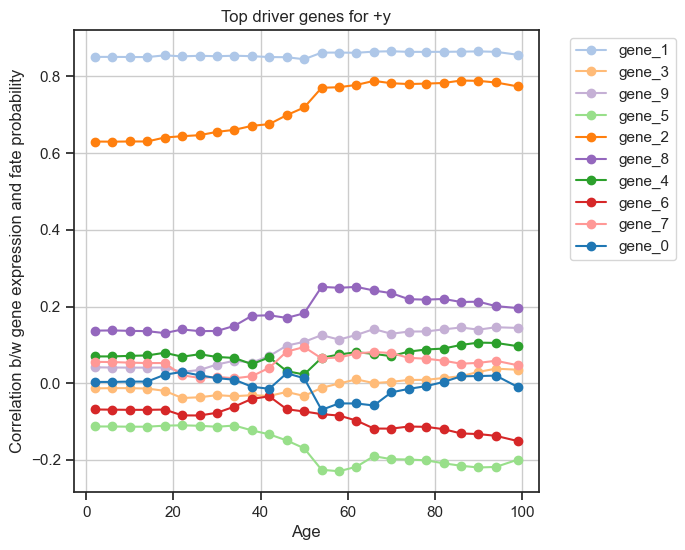

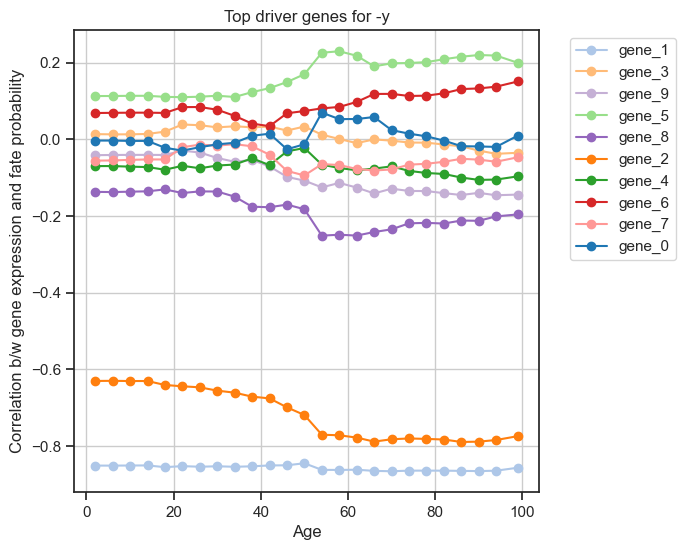

In [7]:
from gstatot import gene_selection
dg_identifier = gene_selection(adata=gSOT.adata,
                                 adata_keys=adata_keys)

fate_names = np.unique(sim_adata.obs[adata_keys['cell_type_key']])
dg_identifier.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
dg_identifier.plot_top_corr_over_age(fate_names=['+y', '-y'], n_top_genes=10)

# StatOT

Using optimal parameters for T=25: epsilon=0.075
Cost scaled by  mean
Time 2.0, ran 5000 iterations, inf norm error: 8.9407e-08
Time 6.0, ran 5000 iterations, inf norm error: 2.2352e-08
Time 10.0, ran 5000 iterations, inf norm error: 3.7253e-08
Time 14.0, ran 5000 iterations, inf norm error: 1.0431e-07
Time 18.0, ran 5000 iterations, inf norm error: 3.9846e-05
Time 18.0, ran 10000 iterations, inf norm error: 3.9846e-05
Time 18.0, ran 15000 iterations, inf norm error: 3.9846e-05
Time 22.0, ran 5000 iterations, inf norm error: 7.4506e-08
Time 26.0, ran 5000 iterations, inf norm error: 3.7253e-08
Time 30.0, ran 5000 iterations, inf norm error: 5.2154e-08
Time 34.0, ran 5000 iterations, inf norm error: 3.7253e-08
Time 38.0, ran 5000 iterations, inf norm error: 5.2154e-08
Time 42.0, ran 5000 iterations, inf norm error: 7.6815e-06
Time 46.0, ran 5000 iterations, inf norm error: 8.1956e-08
Time 50.0, ran 5000 iterations, inf norm error: 2.9802e-08
Time 54.0, ran 5000 iterations, inf norm erro

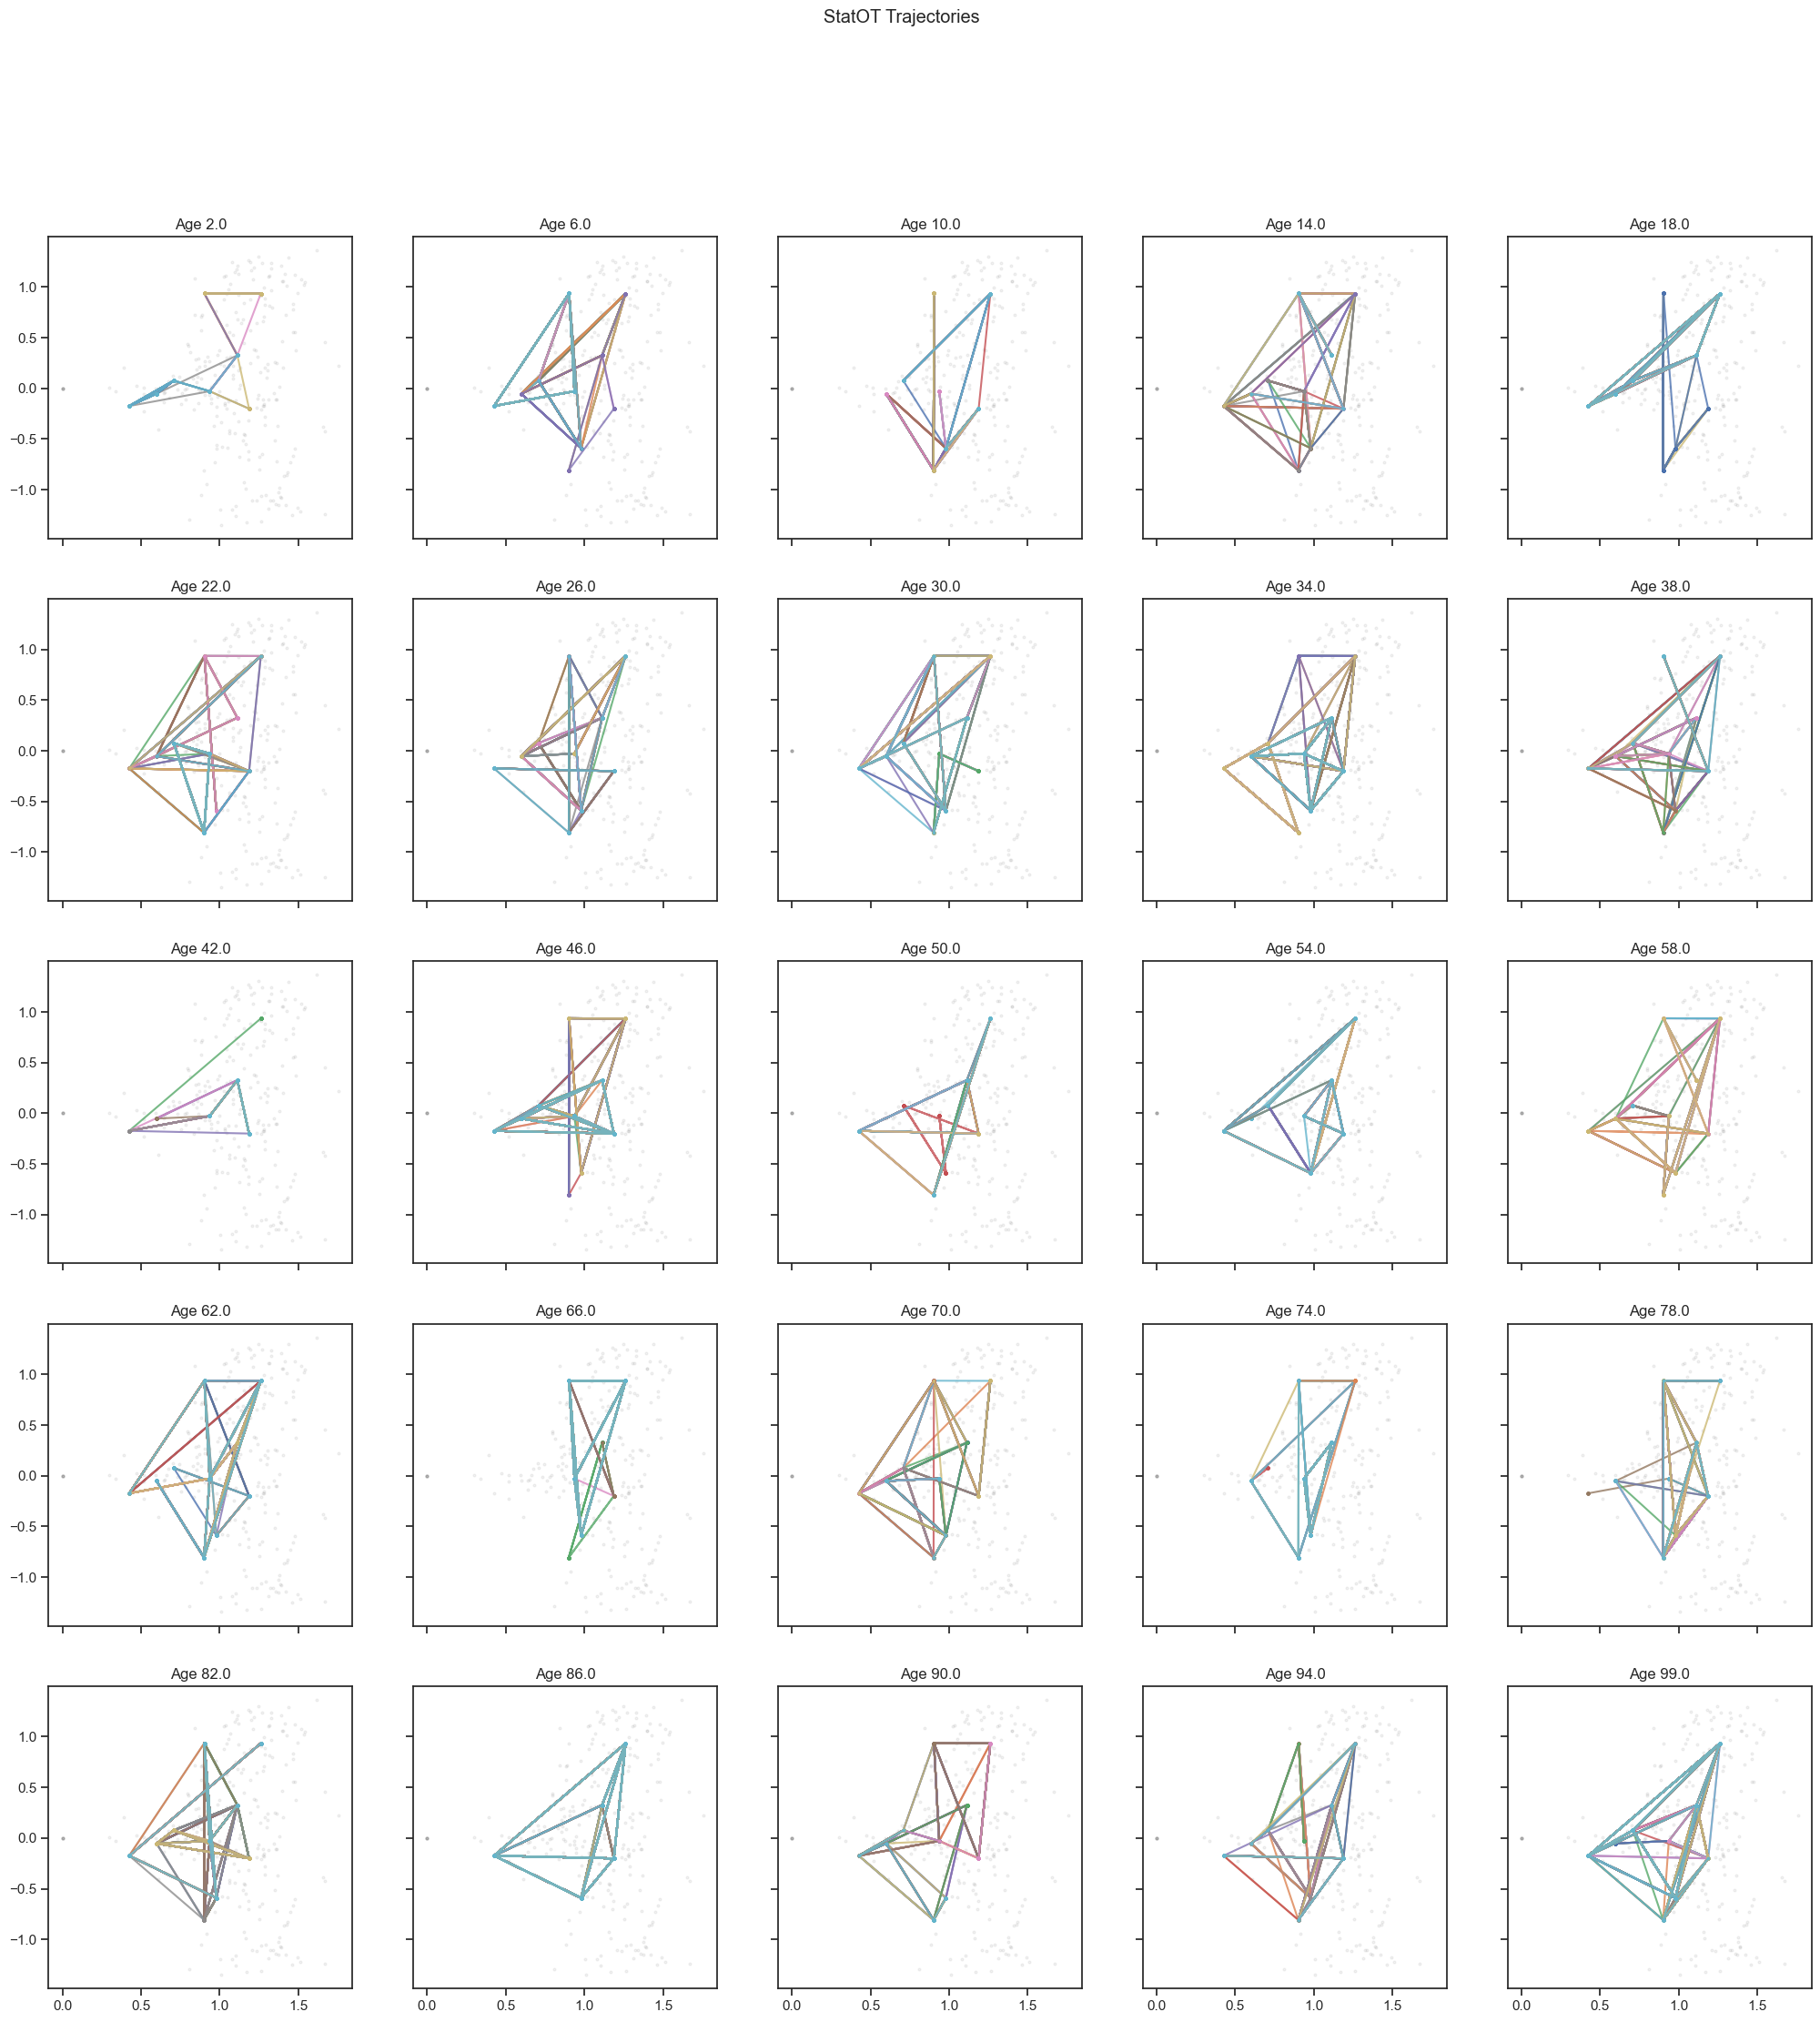

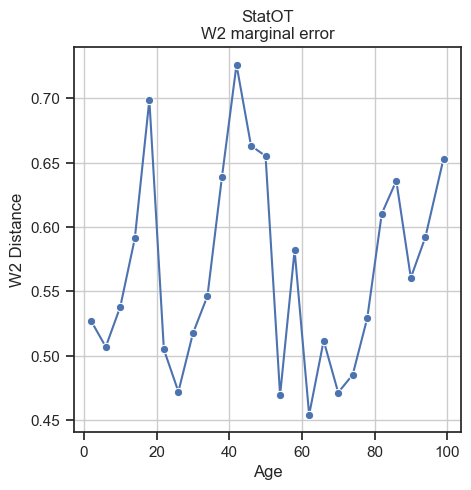

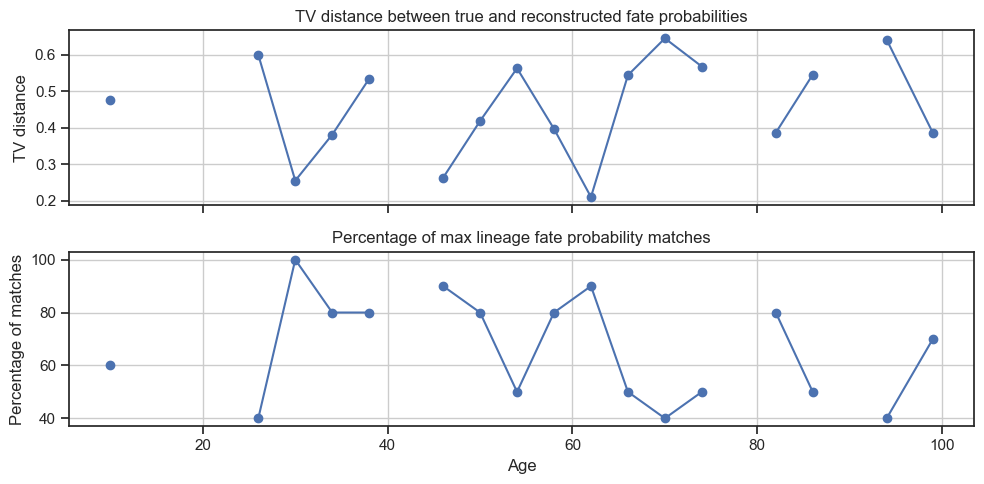

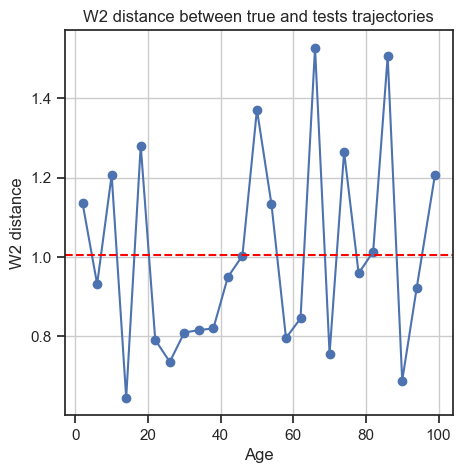

In [8]:
SOT = StatOT(adata=downsampled_adata.copy(), adata_keys=adata_keys, dt=dt, dtype=jnp.float32)

opt_params_SOT = pd.read_csv('../extra/sweeps/sim/StatOT_opt_vals_sim.csv', index_col=0)
epsilon = opt_params_SOT.loc[T]['epsilon']
print(f"Using optimal parameters for T={T}: epsilon={epsilon}")
SOT_params = {'epsilon': epsilon,
              'lse': True,
              'cost_scaling': 'mean'}

SOT.fit(model_params=SOT_params, max_iter=15_000, verbose=True)

SOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
SOT.get_trajectories(num_step=num_step, num_traj=num_traj, plot_traj=True)
method_str = 'StatOT' 

sot_metric_tests = Metric_Evaluator(method=method_str,
                                        test_adata=SOT.adata,
                                        true_adata=sim_adata,
                                        time_key=adata_keys['time_key'],
                                        embed_key=adata_keys['embed_key'],
                                        exp_dir=None,
                                        full_supp=False)

sot_metric_tests.w2_marginal_error()
sot_metric_tests.fp_tv_error(label_key=adata_keys['cell_type_key'])

sot_metric_tests.w2_trajectory_error(test_dt=dt, true_dt=sim_dt)


### Gene fitting

100%|██████████| 25/25 [00:00<00:00, 43.74it/s]


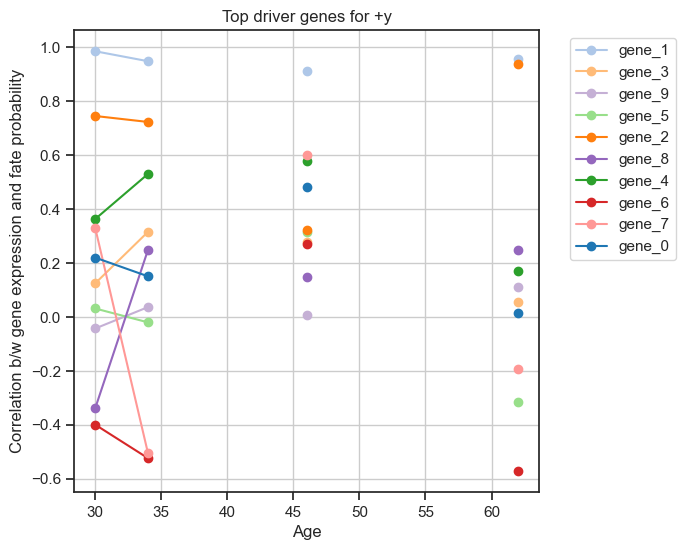

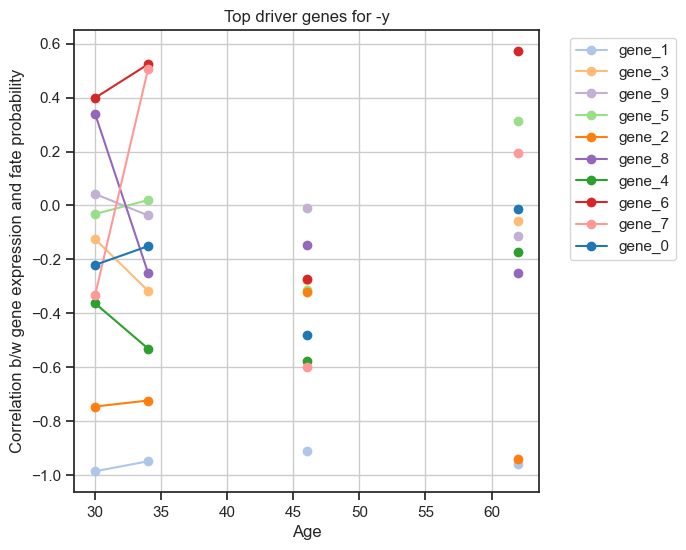

In [9]:

sot_dg_identifier = gene_selection(adata=SOT.adata,
                                 adata_keys=adata_keys, full_supp=False)

sot_dg_identifier.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
sot_dg_identifier.plot_top_corr_over_age(n_top_genes=10, fate_names=['+y', '-y'], rank_by_abs_corr=True)

# Compare

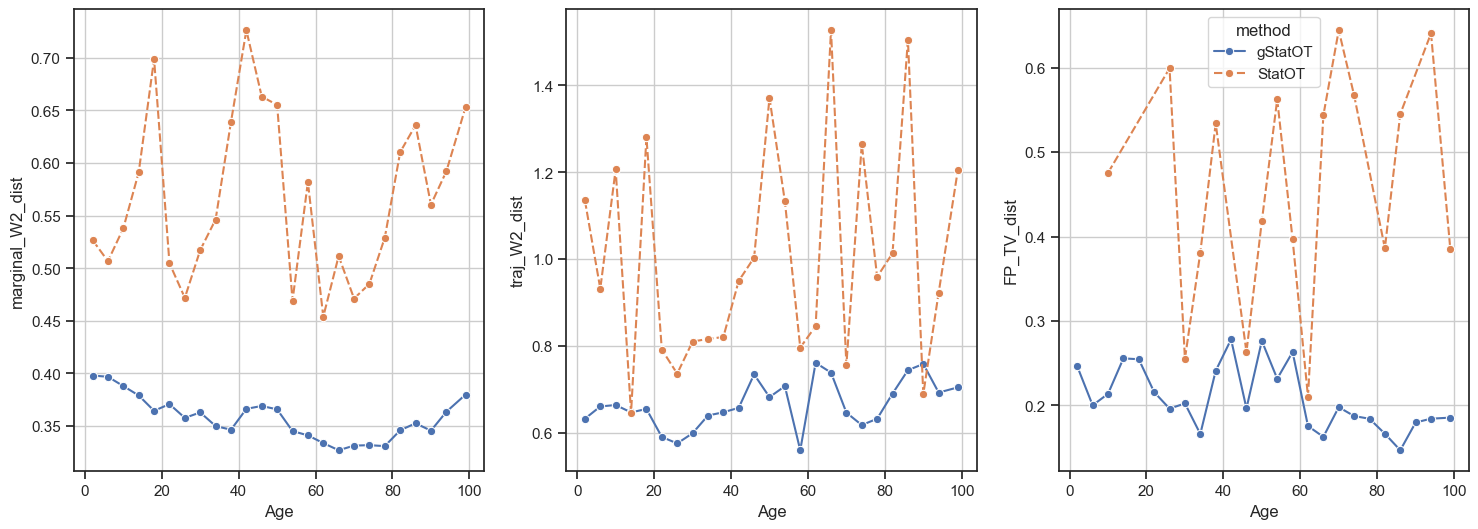

In [11]:
df_all = pd.concat([gsot_metric_tests.results_df, sot_metric_tests.results_df]).reset_index(drop=True)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.lineplot(data=df_all, x='Age', y='marginal_W2_dist', hue='method', style='method', marker='o', ax=axs[0])
axs[0].legend().remove()
axs[0].grid()
sns.lineplot(data=df_all, x='Age', y='traj_W2_dist', hue='method', style='method', marker='o', ax=axs[1])
axs[1].legend().remove()
axs[1].grid()
sns.lineplot(data=df_all, x='Age', y='FP_TV_dist', hue='method', style='method', marker='o', ax=axs[2])
axs[2].grid()